# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


**Define Project**

Project Link: https://www.kaggle.com/competitions/playground-series-s4e1
Challenge: A bank wants to predict which customers will churn (leave the bank) based on demographic and account information. This is a binary classification task — predict Exited = 1 (churned) or Exited = 0 (stayed).
Data: Synthetically generated from a real bank churn dataset. ~165,000 training rows, ~110,000 test rows. 13 features including a mix of numerical features like Age, Balance, and CreditScore, and categorical features like Geography and Gender. Evaluation metric is ROC-AUC.

In [12]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print(train.head())

Train shape: (165034, 14)
Test shape:  (110023, 13)
   id  CustomerId         Surname  CreditScore Geography Gender   Age  Tenure  \
0   0    15674932  Okwudilichukwu          668    France   Male  33.0       3   
1   1    15749177   Okwudiliolisa          627    France   Male  33.0       1   
2   2    15694510           Hsueh          678    France   Male  40.0      10   
3   3    15741417             Kao          581    France   Male  34.0       2   
4   4    15766172       Chiemenam          716     Spain   Male  33.0       5   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              2        1.0             0.0        181449.97   
1       0.00              2        1.0             1.0         49503.50   
2       0.00              2        1.0             0.0        184866.69   
3  148882.54              1        1.0             1.0         84560.88   
4       0.00              2        1.0             1.0         15068.83   

   Exited 

In [2]:
print(train.isnull().sum())

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [3]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
print(train[num_cols].describe().round(2))

for col in ["Geography", "Gender", "HasCrCard", "IsActiveMember"]:
    print(f"\n{col}:\n", train[col].value_counts())

       CreditScore        Age     Tenure    Balance  NumOfProducts  \
count    165034.00  165034.00  165034.00  165034.00      165034.00   
mean        656.45      38.13       5.02   55478.09           1.55   
std          80.10       8.87       2.81   62817.66           0.55   
min         350.00      18.00       0.00       0.00           1.00   
25%         597.00      32.00       3.00       0.00           1.00   
50%         659.00      37.00       5.00       0.00           2.00   
75%         710.00      42.00       7.00  119939.52           2.00   
max         850.00      92.00      10.00  250898.09           4.00   

       EstimatedSalary  
count        165034.00  
mean         112574.82  
std           50292.87  
min              11.58  
25%           74637.57  
50%          117948.00  
75%          155152.47  
max          199992.48  

Geography:
 Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender:
 Gender
Male      93150
Female    7

In [4]:
print("\nTarget distribution:")
print(train["Exited"].value_counts())
print(train["Exited"].value_counts(normalize=True).round(3))


Target distribution:
Exited
0    130113
1     34921
Name: count, dtype: int64
Exited
0    0.788
1    0.212
Name: proportion, dtype: float64


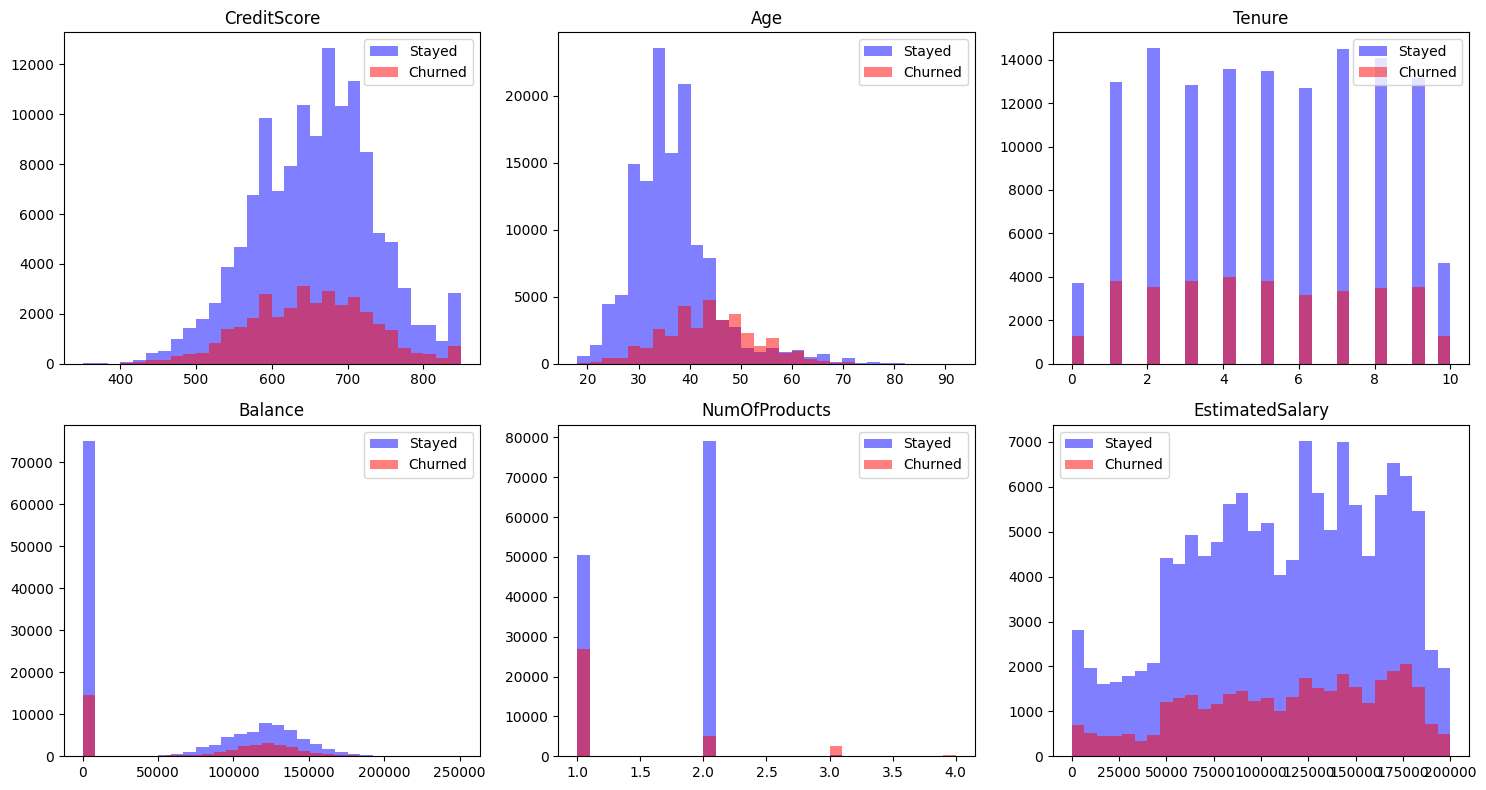

In [ ]:
# visualization

import matplotlib.pyplot as plt

# split into two groups
stayed  = train[train["Exited"] == 0]
churned = train[train["Exited"] == 1]

num_cols = ["CreditScore", "Age", "Tenure", "Balance", 
            "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(stayed[col],  bins=30, alpha=0.5, label="Stayed",  color="blue")
    axes[i].hist(churned[col], bins=30, alpha=0.5, label="Churned", color="red")
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

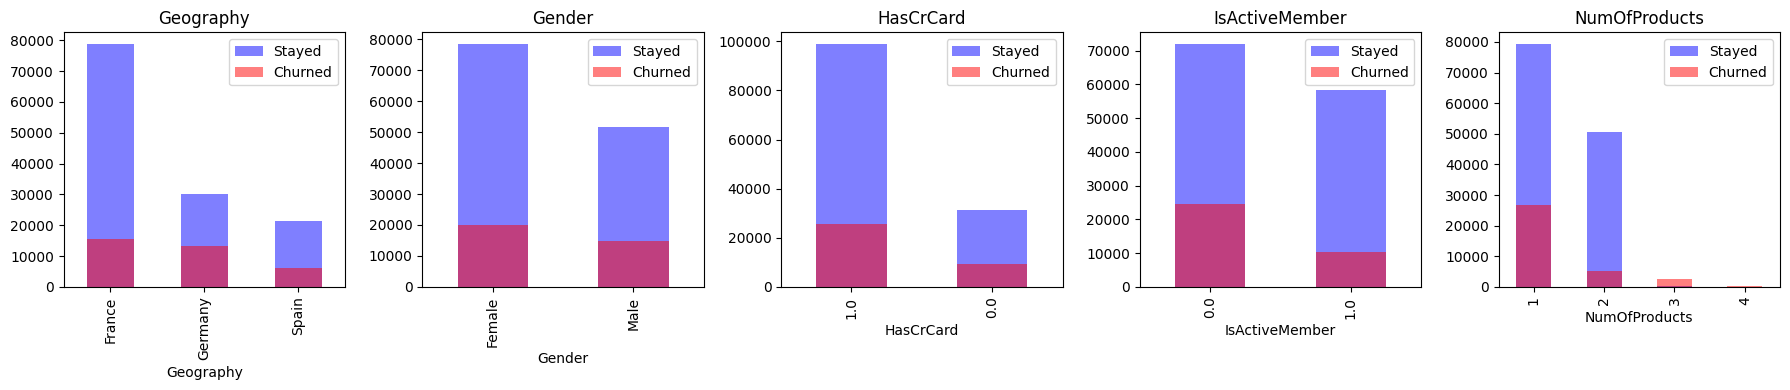

In [6]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(cat_cols):
    stayed[col].value_counts().plot(kind="bar",  ax=axes[i], alpha=0.5, color="blue", label="Stayed")
    churned[col].value_counts().plot(kind="bar", ax=axes[i], alpha=0.5, color="red",  label="Churned")
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

Age and NumOfProducts show the clearest separation between churned and stayed customers, suggesting they will be the most predictive features. IsActiveMember and Geography also show notable differences. CreditScore, Tenure, and EstimatedSalary show little separation and may contribute minimally to model performance.

In [13]:
# preprocessing 
# dropping identification rows with no predictive signal

drop_cols = ["id", "CustomerId", "Surname"]
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

#one hot encoding of categorical variables

train = pd.get_dummies(train, columns=["Geography", "Gender"])
test  = pd.get_dummies(test,  columns=["Geography", "Gender"])

#scaling numerical columns

from sklearn.preprocessing import StandardScaler

scale_cols = ["CreditScore", "Age", "Tenure", "Balance", 
              "NumOfProducts", "EstimatedSalary"]

scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols]  = scaler.transform(test[scale_cols])

print(train.shape)
print(train.columns.tolist())
print(train.head())

(165034, 14)
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']
   CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
0     0.144135 -0.578074 -0.719973 -0.883163       0.814298        1.0   
1    -0.367706 -0.578074 -1.432694 -0.883163       0.814298        1.0   
2     0.268974  0.211354  1.774548 -0.883163       0.814298        1.0   
3    -0.941966 -0.465299 -1.076334  1.486918      -1.013348        1.0   
4     0.743362 -0.578074 -0.007253 -0.883163       0.814298        1.0   

   IsActiveMember  EstimatedSalary  Exited  Geography_France  \
0             0.0         1.369486       0              True   
1             1.0        -1.254085       0              True   
2             0.0         1.437422       0              True   
3             1.0        -0.557018       0              True   
4        

In [ ]:
# ML - training

from sklearn.model_selection import train_test_split

X = train.drop(columns=["Exited"])
y = train["Exited"]

# first split off 20% for final test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# split remaining 80% into train/val (so val is 20% of original)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print("Train size:", X_train.shape)
print("Val size:  ", X_val.shape)
print("Test size: ", X_test.shape)


Train size: (99020, 13)
Val size:   (33007, 13)
Test size:  (33007, 13)


In [15]:
# random forest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
# accuracy

from sklearn.metrics import roc_auc_score, classification_report

val_preds      = model.predict(X_val)
val_preds_prob = model.predict_proba(X_val)[:, 1]

print("Validation AUC:", roc_auc_score(y_val, val_preds_prob))
print(classification_report(y_val, val_preds))

Validation AUC: 0.8729420641884293
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     25982
           1       0.72      0.54      0.61      7025

    accuracy                           0.86     33007
   macro avg       0.80      0.74      0.76     33007
weighted avg       0.85      0.86      0.85     33007



In [19]:
# final honest evaluation on held-out test set

test_preds_prob = model.predict_proba(X_test)[:, 1]
print("Test AUC:", roc_auc_score(y_test, test_preds_prob))

Test AUC: 0.8728766655153993


In [20]:
# apply model to the kaggle test set

kaggle_preds = model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    "id": pd.read_csv("test.csv")["id"],
    "Exited": kaggle_preds
})

submission.to_csv("submission.csv", index=False)
print(submission.head())

       id  Exited
0  165034    0.01
1  165035    0.88
2  165036    0.00
3  165037    0.17
4  165038    0.21
